In [ ]:
"""investigate the small structures around the main dust tail.
    locate them at the initial moment"""

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from ReadParticle import read_particle_frames

filenames = ['particles_5mm.txt']
# filenames = ['particles_1mm.txt', 'particles_3mm.txt', 'particles_4mm.txt', 'particles_5mm.txt',
#              'particles_7mm.txt', 'particles_1cm.txt', 'particles_5cm.txt', 'particles_10cm.txt']

datasets = []
# Read particle data
for file in filenames:
    
    Np_seq, time, r_dust, data_p = read_particle_frames(file)
    dataset = {}
    dataset['Np_seq'] = Np_seq
    dataset['time'] = time
    dataset['r_dust'] = r_dust
    dataset['data_p'] = data_p

    datasets.append(dataset)

num_datasets = len(datasets)

processing completed!


In [2]:
i = 0                # specify a dataset
target_day = 131.29  # specify targetted day
target_seconds = target_day * 86400.
t_idx = np.searchsorted(datasets[i]['time'], target_seconds, side="left")

p_t = datasets[i]['data_p'][t_idx]
day = datasets[i]['time'][t_idx] / 86400.

# matrix convert vector from 'Sun Body Center' to 'Didymos System Barycenter'
SBC_rotate_DSB = np.array([[-0.703595792353257, -0.710438191316344, 0.015183454875444],
                          [ 0.702824020343859, -0.692584740738747,  0.16237232930379 ],
                          [-0.104839674791979,  0.124915784491013,  0.986612735258626]])
# sky north vector and convert it to 'Didymos System Barycenter' frame
sky_north = np.array([0, 0, 1])
r_sky_north = np.dot(SBC_rotate_DSB, sky_north.T)

# position vector of Earth (as a proxy of HST)
r_earth = p_t[3, 1:4]

# calculate the two basis vectors of the projection plane
l1 = np.cross(r_sky_north, r_earth)
l2 = np.cross(r_earth, l1)
l1 = l1 / np.linalg.norm(l1)
l2 = l2 / np.linalg.norm(l2)

# create an array to record coordinates of particles projected onto the plane, and its angle deviated from the honrizontal line.
p_projected = np.zeros((len(p_t),4), dtype=float)
p_projected[:, 0] = p_t[:, 0]                  # copy the column of particle ID
p_projected[:, 1] = np.dot(p_t[:, 1:4], l1)    # x coordinate
p_projected[:, 2] = np.dot(p_t[:, 1:4], l2)    # y coordinate
p_projected[:, 3] = np.arctan(p_projected[:, 2] / p_projected[:, 1]) / np.pi * 180.  # angle

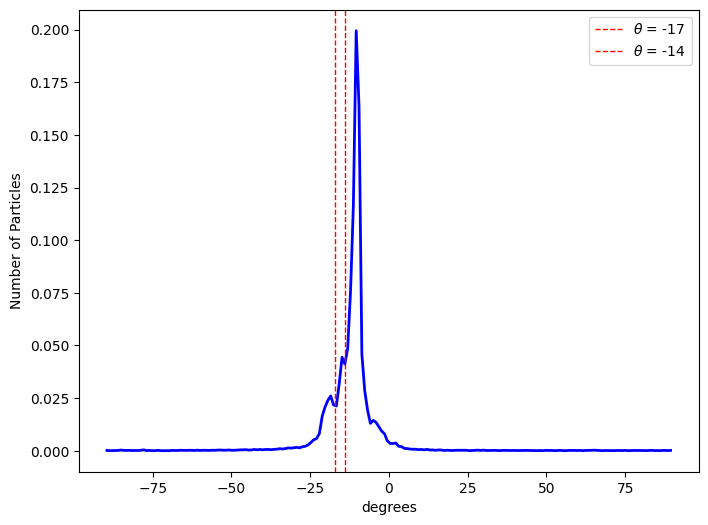

In [3]:
# compute histogram of the angle
counts, bin_edges = np.histogram(p_projected[4:,3], bins=200, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Create distribution of angles
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(bin_centers, counts, color='blue', lw=2, label='')

# specify an angle range containing the interested structure
theta_range = [-17, -14]
ax.axvline(x=theta_range[0], color='red', linestyle='--', linewidth=1, label=f'$\\theta$ = {theta_range[0]}')
ax.axvline(x=theta_range[1], color='red', linestyle='--', linewidth=1, label=f'$\\theta$ = {theta_range[1]}')

#ax.set_yscale('log')
ax.set_xlabel('degrees')
ax.set_ylabel('Number of Particles')
ax.legend()

plt.show()
plt.close(fig)

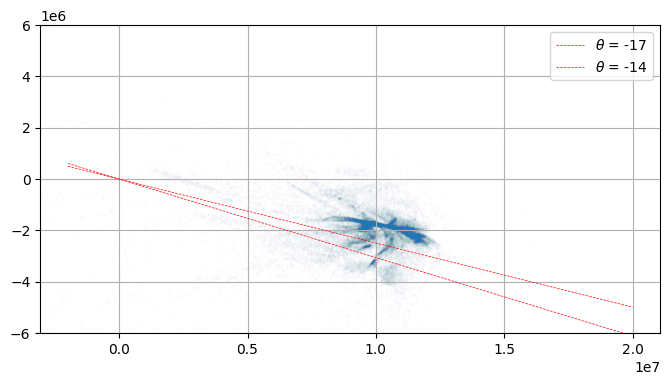

In [7]:
# take a look at the HST view
fig, ax = plt.subplots(figsize=(8,4))
axis_lims = [-2000e3, 20000e3, -6000e3, 6000e3]

ax.scatter(p_projected[4:, 1],
           p_projected[4:, 2],
           s=0.5,
           alpha=0.01)

# draw a slope line
for theta in theta_range:
    slope = np.tan(theta/180.*np.pi)
    x_values = np.array([axis_lims[0], axis_lims[1]])
    y_values = slope * x_values
    ax.plot(x_values, y_values, color='red', linestyle='--', linewidth=0.5, label=f'$\\theta$ = {theta}')

ax.axis('equal')
ax.set_xlim(axis_lims[0], axis_lims[1])
ax.set_ylim(axis_lims[2], axis_lims[3])
ax.grid()
ax.legend()

plt.show()
plt.close(fig)

In [9]:
#
# Select particles within the angle range
p_sel = p_projected[(p_projected[:, 3] > theta_range[0]) & (p_projected[:, 3] < theta_range[1])]

print(selected_rows)


[[ 3.60000000e+01  1.10791119e+07 -3.27534144e+06 -1.64693722e+01]
 [ 4.70000000e+01  1.12541770e+07 -2.98160137e+06 -1.48386329e+01]
 [ 4.80000000e+01  1.11784738e+07 -3.12528524e+06 -1.56199652e+01]
 ...
 [ 4.53000000e+04  1.12775652e+07 -2.99927295e+06 -1.48930958e+01]
 [ 4.53060000e+04  1.07364626e+07 -2.70488238e+06 -1.41404998e+01]
 [ 4.53160000e+04  1.22174495e+07 -3.16622309e+06 -1.45289013e+01]]


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Example data
p_data = p_projected

# Function to plot data within the specified angle range
def plot_filtered_data(angle_min=-17, angle_max=-14):
    # Filter rows based on angle range
    filtered_data = p_data[(p_data[:, 3] >= angle_min) & (p_data[:, 3] <= angle_max)]
    
    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(8,4))
    axis_lims = [-2000e3, 20000e3, -6000e3, 6000e3]
    
    ax.scatter(filtered_data[:, 1], filtered_data[:, 2], c=filtered_data[:, 3], cmap='viridis', s=0.5, alpha=0.01)
    #plt.colorbar(label="Angle (degrees)")
    
    ax.axis('equal')
    ax.set_xlim(axis_lims[0], axis_lims[1])
    ax.set_ylim(axis_lims[2], axis_lims[3])
    ax.set_xlabel("X / m")
    ax.set_ylabel("Y / m")
    ax.set_title(f"Particles with Angle in [{angle_min}, {angle_max}]")
    ax.grid()
    ax.legend()
    plt.show()

# Interactive slider for angle range
interact(
    plot_filtered_data, 
    angle_min=FloatSlider(value=-17, min=-25, max=0, step=0.1, description="Angle Min"),
    angle_max=FloatSlider(value=-14, min=-25, max=0, step=0.1, description="Angle Max")
)


interactive(children=(FloatSlider(value=-17.0, description='Angle Min', max=0.0, min=-25.0), FloatSlider(value…

<function __main__.plot_filtered_data(angle_min=-17, angle_max=-14)>